In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score

import torch
from torch.utils.data import DataLoader

import sys
sys.path.insert(0, r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src")

from cbl.data.ir_dataset import IRDataset
from cbl.data.transforms import Interpolate
from cbl.utils import get_labels



In [10]:
MERGED_PATH = r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src\cbl\data\merged.parquet"
LAB_PATH    = r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src\cbl\data\lab_resampled.parquet"

CLASS_NAMES = ['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino']

df = pd.read_parquet(MERGED_PATH)
print(f"Full merged dataset: {len(df)} samples")
print("\nClass counts (merged):")
for col in CLASS_NAMES:
    print(f"  {col}: {int(df[col].sum())} ({df[col].mean()*100:.2f}%)")

Full merged dataset: 191872 samples

Class counts (merged):
  carboxylic_acid: 79005 (41.18%)
  amino: 116276 (60.60%)
  sulfonic_acid: 77 (0.04%)
  guanidino: 3145 (1.64%)


In [5]:
mask_rare = (df['sulfonic_acid'] == 1) | (df['guanidino'] == 1)
df_rare   = df[mask_rare]
df_common = df[~mask_rare].sample(n=10_000, random_state=42)
df_sub    = pd.concat([df_rare, df_common]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Subset size: {len(df_sub)} samples")
for col in CLASS_NAMES:
    print(f"  {col}: {int(df_sub[col].sum())}")

Subset size: 13215 samples
  carboxylic_acid: 4427
  amino: 7820
  sulfonic_acid: 77
  guanidino: 3145


In [21]:
transform = Interpolate((4000, 400), 1800)

spectra_list = []
for _, row in df_sub.iterrows():
    wn = np.asarray(row['wavenumber'])
    tr = np.asarray(row['transmittance'])
    spectra_list.append(transform(wn, tr))

X = np.stack(spectra_list)
y = df_sub[CLASS_NAMES].values

strata = df_sub['sulfonic_acid'].astype(str) + df_sub['guanidino'].astype(str)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=strata
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Spectra range: [{X.min():.3f}, {X.max():.3f}]")

Train: (11232, 1800)
Val:   (1983, 1800)
Spectra range: [0.000, 1.000]


In [26]:
ADULTERANT_SMILES = {
    'creatine': 'CN(CC(=O)O)C(=N)N',
    'taurine':  'NCCS(=O)(=O)O',
    'glycine':  'NCC(=O)O',
}

lab_raw = pd.read_parquet(r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src\cbl\data\lab_resampled.parquet")

# Pure base rows (no adulterant) get all-zero labels — they are negative controls
lab_raw['smiles'] = lab_raw['adulterant'].map(ADULTERANT_SMILES)

def assign_labels(row):
    if pd.isna(row['smiles']):
        # pure base — no adulterant functional groups present
        return {col: 0 for col in CLASS_NAMES}
    return get_labels(row['smiles'])

label_df = pd.DataFrame(
    lab_raw.apply(assign_labels, axis=1).tolist(),
    index=lab_raw.index
)
lab_raw = pd.concat([lab_raw, label_df], axis=1)

# Apply same Interpolate transform
lab_spectra = []
for _, row in lab_raw.iterrows():
    wn = np.asarray(row['wavenumber'])
    tr = np.asarray(row['transmittance'])
    lab_spectra.append(transform(wn, tr))

X_lab = np.stack(lab_spectra)
y_lab = lab_raw[CLASS_NAMES].values.astype(int)

print(f"Lab samples: {X_lab.shape[0]}")
print(f"Lab spectra range: [{X_lab.min():.3f}, {X_lab.max():.3f}]")
print("\nLab label counts:")
for col in CLASS_NAMES:
    print(f"  {col}: {int(lab_raw[col].sum())}")
print("\nSamples per adulterant:")
print(lab_raw.groupby(lab_raw['adulterant'].fillna('pure (negative control)'))['concentration'].apply(list))

Lab samples: 23
Lab spectra range: [0.000, 1.000]

Lab label counts:
  carboxylic_acid: 14
  amino: 21
  sulfonic_acid: 7
  guanidino: 7

Samples per adulterant:
adulterant
creatine                   [0.1, 0.25, 1.0, 0.1, 0.25, 0.5, 0.5]
glycine                    [0.1, 0.25, 1.0, 0.1, 0.25, 0.5, 0.5]
pure (negative control)                               [0.0, 0.0]
taurine                    [0.1, 0.25, 1.0, 0.1, 0.25, 0.5, 0.5]
Name: concentration, dtype: object


In [23]:
print("Training Random Forest (balanced_subsample) …")
rf = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators = 300,
        class_weight = 'balanced_subsample',
        random_state = 42,
        n_jobs       = -1,
    )
)
rf.fit(X_train, y_train)
print("Done")

Training Random Forest (balanced_subsample) …
Done


In [16]:
optimal_thresholds = [0.45, 0.60, 0.15, 0.35]

In [24]:
y_proba_val = np.array([est.predict_proba(X_val)[:, 1]
                        for est in rf.estimators_]).T

thresholds_to_try = np.arange(0.05, 0.65, 0.05)
optimal_thresholds = []

print("Optimal thresholds on validation set:")
for i, class_name in enumerate(CLASS_NAMES):
    best_t, best_f1 = 0.5, 0
    for t in thresholds_to_try:
        preds = (y_proba_val[:, i] > t).astype(int)
        f1 = f1_score(y_val[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    optimal_thresholds.append(best_t)
    print(f"  {class_name:<20}: threshold={best_t:.2f}  val F1={best_f1:.3f}")

Optimal thresholds on validation set:
  carboxylic_acid     : threshold=0.45  val F1=0.971
  amino               : threshold=0.60  val F1=0.990
  sulfonic_acid       : threshold=0.35  val F1=0.500
  guanidino           : threshold=0.35  val F1=0.876


In [27]:
y_proba_lab = np.array([est.predict_proba(X_lab)[:, 1]
                        for est in rf.estimators_]).T

y_pred_lab = np.column_stack([
    (y_proba_lab[:, i] > optimal_thresholds[i]).astype(int)
    for i in range(len(CLASS_NAMES))
])

print("RF — lab test set — tuned thresholds:")
print(classification_report(y_lab, y_pred_lab, target_names=CLASS_NAMES, zero_division=0))
print(f"Macro F1:    {f1_score(y_lab, y_pred_lab, average='macro',    zero_division=0):.3f}")
print(f"Weighted F1: {f1_score(y_lab, y_pred_lab, average='weighted', zero_division=0):.3f}")

RF — lab test set — tuned thresholds:
                 precision    recall  f1-score   support

carboxylic_acid       0.00      0.00      0.00        14
          amino       0.00      0.00      0.00        21
  sulfonic_acid       0.60      0.86      0.71         7
      guanidino       0.33      1.00      0.50         7

      micro avg       0.42      0.27      0.33        49
      macro avg       0.23      0.46      0.30        49
   weighted avg       0.13      0.27      0.17        49
    samples avg       0.43      0.23      0.29        49

Macro F1:    0.301
Weighted F1: 0.172


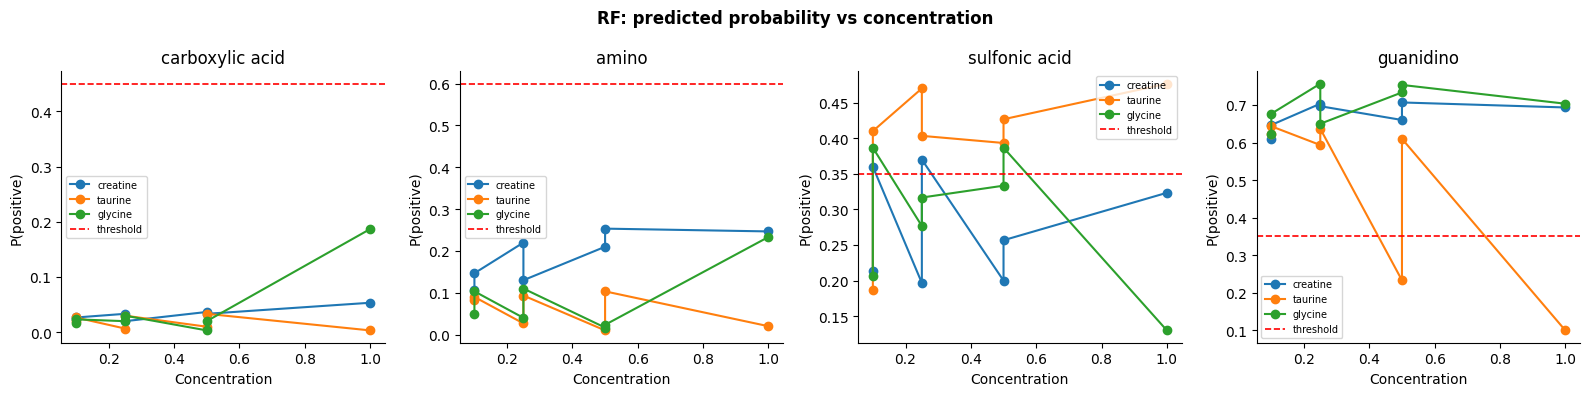

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('RF: predicted probability vs concentration', fontweight='bold')

# Only plot adulterant rows for the concentration trend
lab_adult = lab_raw[lab_raw['adulterant'].notna()].copy().reset_index(drop=True)
y_proba_adult = y_proba_lab[lab_raw['adulterant'].notna().values]

for i, (ax, col) in enumerate(zip(axes, CLASS_NAMES)):
    for adult in lab_adult['adulterant'].unique():
        mask  = (lab_adult['adulterant'] == adult).values
        conc  = lab_adult.loc[mask, 'concentration'].values
        proba = y_proba_adult[mask, i]
        # sort by concentration for clean lines
        order = np.argsort(conc)
        ax.plot(conc[order], proba[order], marker='o', label=adult)
    ax.axhline(optimal_thresholds[i], color='red', ls='--', lw=1.2, label='threshold')
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Concentration')
    ax.set_ylabel('P(positive)')
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

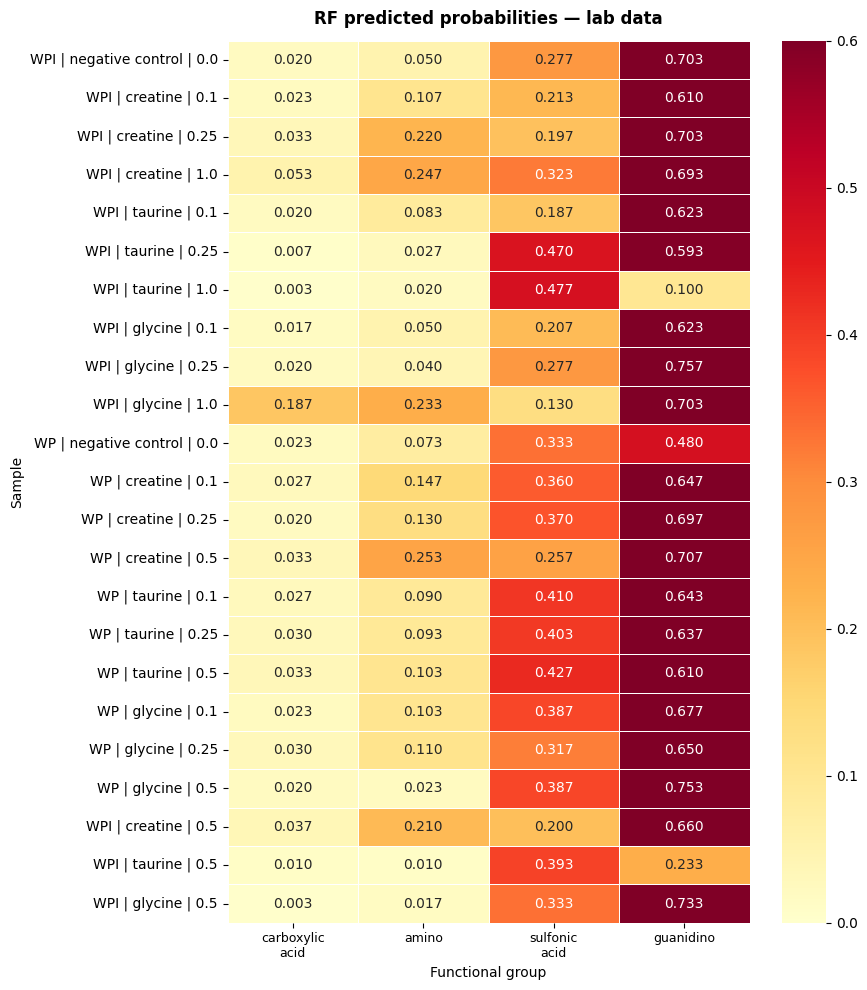

In [ ]:
sample_labels = []
for _, row in lab_raw.iterrows():
    base  = row['base'].replace('whey protein isolate', 'WPI').replace('whey protein', 'WP')
    adult = row['adulterant'] if pd.notna(row['adulterant']) else 'negative control'
    sample_labels.append(f"{base} | {adult} | {row['concentration']}")

proba_df = pd.DataFrame(y_proba_lab, columns=CLASS_NAMES, index=sample_labels)

fig, ax = plt.subplots(figsize=(9, 10))
sns.heatmap(
    proba_df,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    vmin=0, vmax=0.6,
    linewidths=0.5,
    ax=ax
)
ax.set_title('RF predicted probabilities — lab data', fontweight='bold', pad=12)
ax.set_xlabel('Functional group')
ax.set_ylabel('Sample')
ax.set_xticklabels([c.replace('_', '\n') for c in CLASS_NAMES], fontsize=9)
plt.tight_layout()
plt.show()

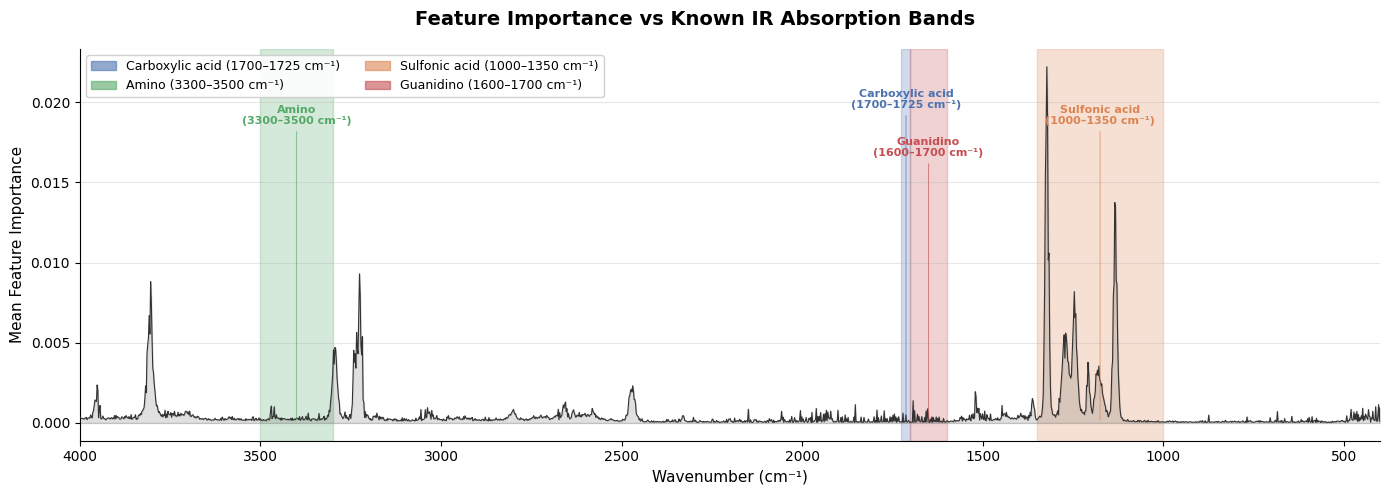

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

importances = np.mean([est.feature_importances_ for est in rf.estimators_], axis=0)
wavenumbers = np.linspace(4000, 400, 1800)

ABSORPTION_BANDS = {
    'Carboxylic acid\n(1700–1725 cm⁻¹)': (1700, 1725, '#4C72B0'),
    'Amino\n(3300–3500 cm⁻¹)':           (3300, 3500, '#55A868'),
    'Sulfonic acid\n(1000–1350 cm⁻¹)':   (1000, 1350, '#DD8452'),
    'Guanidino\n(1600–1700 cm⁻¹)':       (1600, 1700, '#C44E52'),
}

# Stagger heights for overlapping labels (carboxylic/guanidino are close)
LABEL_HEIGHTS = {
    'Carboxylic acid\n(1700–1725 cm⁻¹)': 0.0195,
    'Amino\n(3300–3500 cm⁻¹)':           0.0185,
    'Sulfonic acid\n(1000–1350 cm⁻¹)':   0.0185,
    'Guanidino\n(1600–1700 cm⁻¹)':       0.0165,  # lower to avoid overlap with carboxylic
}

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Feature Importance vs Known IR Absorption Bands',
             fontsize=14, fontweight='bold')

ax.plot(wavenumbers, importances, color='#333333', lw=0.8, zorder=3)
ax.fill_between(wavenumbers, importances, alpha=0.15, color='#333333', zorder=2)

for label, (lo, hi, color) in ABSORPTION_BANDS.items():
    ax.axvspan(lo, hi, alpha=0.25, color=color, zorder=1)
    mid = (lo + hi) / 2
    ax.annotate(
        label,
        xy=(mid, 0),
        xytext=(mid, LABEL_HEIGHTS[label]),
        ha='center', va='bottom',
        fontsize=8, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.6)
    )

ax.set_xlim(4000, 400)
ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=11)
ax.set_ylabel('Mean Feature Importance', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

patches = [mpatches.Patch(color=c, alpha=0.6, label=l.replace('\n', ' '))
           for l, (_, _, c) in ABSORPTION_BANDS.items()]
ax.legend(handles=patches, fontsize=9, loc='upper left', framealpha=0.9, ncol=2)

plt.tight_layout()
plt.show()